# **Pre-Processing**

**Datengrundlage:** Die Aufnahmen stammen von einer DJI-Kamera, frontal am Fahrradlenker
montiert. Das Material liegt als Full HD (1920 × 1080) mit 60 fps im `.mp4`-Format vor
und befindet sich im Ordner `dataset/`.

**Ablauf des Notebooks:**

1. **Frame-Extraktion** – Aus jedem Video wird ein Bild pro Sekunde extrahiert und unter
   `dataset/<videoname>/frames/` gespeichert.
2. **Experimentelle Transformationen** – Aus den extrahierten Frames werden zusätzliche
   Bildrepräsentationen erzeugt (Graustufen, Grünanteil, Kanten/Kontraste, vertikale,
   horizontale und diagonale Linien) und jeweils in eigene Unterordner gespeichert.

Diese aufbereiteten Bilder dienen als Grundlage für die nachgelagerte Analyse
(YOLO-Objektdetektion, HSV-Grünanteil, Oberflächen-Klassifikation).


## 1. Setup & Imports
`pip install opencv-python numpy matplotlib`

In [1]:
from __future__ import annotations

from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

print(f"OpenCV-Version: {cv2.__version__}")

OpenCV-Version: 4.13.0


## 2. Konfiguration

In [5]:
VIDEO_DIR = Path("dataset/raw")
OUTPUT_DIR = Path("dataset/frames")

FRAMES_PER_SECOND = 1
JPEG_QUALITY = 95
OVERWRITE = False

VIDEO_SUFFIXES = {".mp4", ".mov", ".avi"}
video_paths = sorted(
    p for p in VIDEO_DIR.glob("*")
    if p.is_file() and p.suffix.lower() in VIDEO_SUFFIXES
)

print(f"Gefundene Videos in '{VIDEO_DIR}/': {len(video_paths)}")
for p in video_paths:
    print(f"  - {p.name}")

if not video_paths:
    print("\nKeine Videos gefunden. Bitte .mp4-Dateien in den Ordner 'dataset/' legen.")

Gefundene Videos in 'dataset\raw/': 2
  - DJI_0375.MP4
  - DJI_0380.MP4


## 3. Frame-Extraktion (1 Bild pro Sekunde)

Die folgende Funktion liest ein Video ein und speichert pro Sekunde ein Bild. Über die
tatsächliche Bildrate (fps) des Videos wird berechnet, jedes wievielte Frame gespeichert
werden muss. Die Bilder werden fortlaufend nummeriert nach `dataset/<videoname>/frames/`
geschrieben.


In [3]:
def extract_frames(
    video_path: Path,
    output_dir: Path,
    frames_per_second: int = 1,
    overwrite: bool = False,
) -> list[Path]:

    output_dir.mkdir(parents=True, exist_ok=True)

    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Video konnte nicht geöffnet werden: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS) or 0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    if fps <= 0:
        cap.release()
        raise RuntimeError(f"Ungültige Bildrate (fps={fps}) für: {video_path}")

    step = max(1, round(fps / frames_per_second))
    duration_s = total_frames / fps if total_frames else 0

    print(f"▶ {video_path.name}: {width}x{height}, {fps:.2f} fps, "
          f"{total_frames} Frames (~{duration_s:.0f}s) → jedes {step}. Frame")

    saved_paths: list[Path] = []
    frame_idx = 0
    saved_idx = 0

    while True:
        success, frame = cap.read()
        if not success:
            break

        if frame_idx % step == 0:
            out_path = output_dir / f"frame_{saved_idx:05d}.jpg"
            if overwrite or not out_path.exists():
                cv2.imwrite(str(out_path), frame,
                            [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY])
            saved_paths.append(out_path)
            saved_idx += 1

        frame_idx += 1

    cap.release()
    print(f"  ✅ {len(saved_paths)} Frames gespeichert in '{output_dir}'")
    return saved_paths

In [8]:
frames_by_video: dict[str, list[Path]] = {}

for video_path in video_paths:
    video_name = video_path.stem
    frames_dir = OUTPUT_DIR / video_name / "original"

    existing_frames = sorted(frames_dir.glob("frame_*.jpg")) if frames_dir.exists() else []
    if existing_frames and not OVERWRITE:
        print(f"⏭ {video_path.name}: {len(existing_frames)} Frames bereits vorhanden "
              f"in '{frames_dir}' → übersprungen")
        frames_by_video[video_name] = existing_frames
        continue

    saved = extract_frames(
        video_path,
        frames_dir,
        frames_per_second=FRAMES_PER_SECOND,
        overwrite=OVERWRITE,
    )
    frames_by_video[video_name] = saved

print("\nFertig. Frames pro Video:")
for name, paths in frames_by_video.items():
    print(f"  {name}: {len(paths)} Bilder")


⏭ DJI_0375.MP4: 354 Frames bereits vorhanden in 'dataset\frames\DJI_0375\original' → übersprungen
▶ DJI_0380.MP4: 1920x1080, 59.94 fps, 24480 Frames (~408s) → jedes 60. Frame
  ✅ 408 Frames gespeichert in 'dataset\frames\DJI_0380\original'

Fertig. Frames pro Video:
  DJI_0375: 354 Bilder
  DJI_0380: 408 Bilder


## 4. Experimentelle Transformationen

Aus den extrahierten Frames werden verschiedene Bildrepräsentationen erzeugt, die einzelne
visuelle Merkmale hervorheben. Jede Transformation wird in einen eigenen Unterordner unter
`dataset/<videoname>/` gespeichert.

| Ordner        | Transformation        | Methode                                              |
| ------------- | --------------------- | ---------------------------------------------------- |
| `grayscale`   | Schwarz-Weiß          | `cv2.cvtColor` → Graustufen                          |
| `green`       | Nur Grünanteil        | HSV-Schwellwert, nicht-grüne Pixel werden geschwärzt |
| `contrast`    | Nur Kontraste/Kanten  | Canny-Kantendetektion                                |

> Diese Repräsentationen sind **experimentell** und dienen der explorativen Analyse, welche
> Merkmale für den Bikeability-Score relevant sind.


In [9]:
def to_grayscale(bgr: np.ndarray) -> np.ndarray:
    """Schwarz-Weiß / Graustufen."""
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)


def to_green_only(bgr: np.ndarray) -> np.ndarray:
    """Behält nur grüne Bildbereiche (Vegetation), Rest wird geschwärzt."""
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    # Grün-Bereich im HSV-Farbraum (Hue ~ 35–85)
    lower_green = np.array([35, 40, 40])
    upper_green = np.array([85, 255, 255])
    mask = cv2.inRange(hsv, lower_green, upper_green)
    return cv2.bitwise_and(bgr, bgr, mask=mask)


def to_contrast_edges(bgr: np.ndarray) -> np.ndarray:
    """Nur Kontraste/Kanten via Canny."""
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    gray = cv2.GaussianBlur(gray, (5, 5), 0)
    return cv2.Canny(gray, 80, 180)


TRANSFORMS = {
    "grayscale": to_grayscale,
    "green": to_green_only,
    "contrast": to_contrast_edges,
}

print("Verfügbare Transformationen:", ", ".join(TRANSFORMS))


Verfügbare Transformationen: grayscale, green, contrast


In [10]:
def apply_transforms(
    frame_paths: list[Path],
    video_dir: Path,
    transforms: dict,
    overwrite: bool = False,
) -> None:
    out_dirs = {name: video_dir / name for name in transforms}
    for d in out_dirs.values():
        d.mkdir(parents=True, exist_ok=True)

    for frame_path in frame_paths:
        bgr = cv2.imread(str(frame_path))
        if bgr is None:
            print(f"  ⚠️  Konnte Bild nicht lesen: {frame_path}")
            continue

        for name, func in transforms.items():
            out_path = out_dirs[name] / frame_path.name
            if not overwrite and out_path.exists():
                continue
            result = func(bgr)
            cv2.imwrite(str(out_path), result,
                        [cv2.IMWRITE_JPEG_QUALITY, JPEG_QUALITY])

    counts = {name: len(list(d.glob('*.jpg'))) for name, d in out_dirs.items()}
    print(f"  ✅ '{video_dir.name}': " +
          ", ".join(f"{n}={c}" for n, c in counts.items()))


for video_name, frame_paths in frames_by_video.items():
    video_dir = OUTPUT_DIR / video_name
    print(f"▶ Transformiere {len(frame_paths)} Frames von '{video_name}' ...")
    apply_transforms(frame_paths, video_dir, TRANSFORMS, overwrite=OVERWRITE)

print("\nAlle Transformationen abgeschlossen.")

▶ Transformiere 354 Frames von 'DJI_0375' ...
  ✅ 'DJI_0375': grayscale=354, green=354, contrast=354
▶ Transformiere 408 Frames von 'DJI_0380' ...
  ✅ 'DJI_0380': grayscale=408, green=408, contrast=408

Alle Transformationen abgeschlossen.


## 5. Beispielbilder

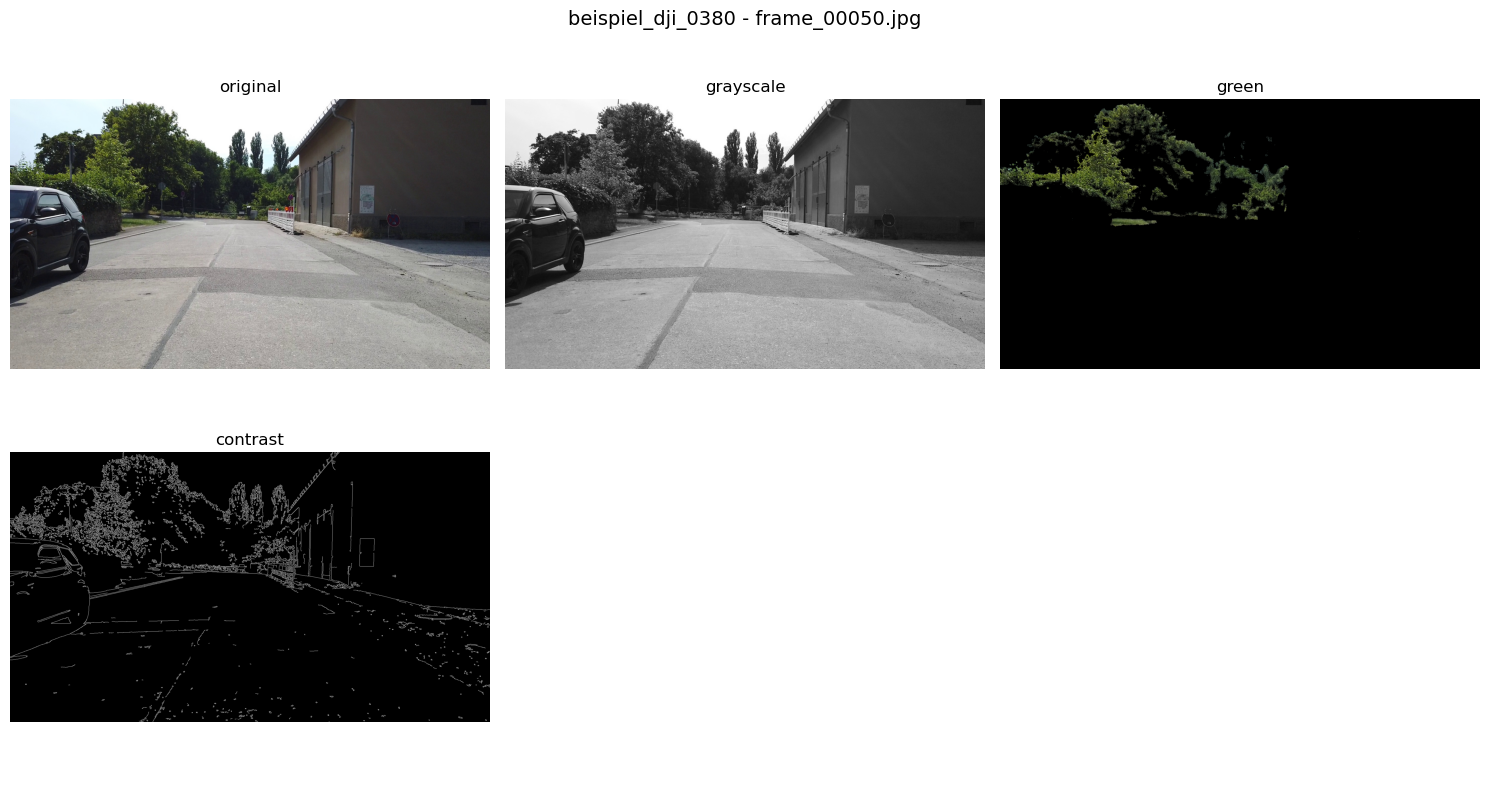

In [16]:
SAMPLE_VIDEO = "beispiel_dji_0380"
SAMPLE_FRAME = "frame_00050.jpg"

sample_path = OUTPUT_DIR / SAMPLE_VIDEO / "original" / SAMPLE_FRAME

if sample_path.exists():
    bgr = cv2.imread(str(sample_path))

    panels = [("original", cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))]
    for name, func in TRANSFORMS.items():
        result = func(bgr)
        if result.ndim == 2:
            panels.append((name, result))
        else:
            panels.append((name, cv2.cvtColor(result, cv2.COLOR_BGR2RGB)))

    n = len(panels)
    cols = 3
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, (title, img) in zip(axes, panels):
        cmap = "gray" if img.ndim == 2 else None
        ax.imshow(img, cmap=cmap)
        ax.set_title(title)
        ax.axis("off")
    for ax in axes[len(panels):]:
        ax.axis("off")

    fig.suptitle(f"{SAMPLE_VIDEO} - {sample_path.name}", fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print(f"Frame nicht gefunden: {sample_path}")
